# Comparative Analysis of Keras and PyTorch Models

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 2

**Objective:** Load the previously trained Keras and PyTorch classifiers,
run both on the same held-out data, and compare their performance using
framework-independent metrics (accuracy, precision, recall, F1, ROC/AUC).

**Prerequisite:** run the previous two labs first, so that
`keras_cnn_classifier.keras` and `pytorch_cnn_classifier.pt`
exist in the working directory.


## 1. Import libraries and data preparation

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("images_dataSAT")
MODELS_DIR = Path(".")
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

assert (MODELS_DIR / "keras_cnn_classifier.keras").exists(), \
    "Keras model not found -- run the Keras training lab first."
assert (MODELS_DIR / "pytorch_cnn_classifier.pt").exists(), \
    "PyTorch model not found -- run the PyTorch training lab first."


I0000 00:00:1782893858.792035    2636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782893858.834713    2636 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782893860.196140    2636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Build a shared, identical validation split

To make the comparison fair, we use the *same* held-out 20% split (same
seed, same underlying `ImageFolder` ordering) for both frameworks.


In [2]:
eval_transform = transforms.Compose([transforms.ToTensor()])
full_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=eval_transform)
class_to_idx = full_dataset.class_to_idx
print("Class mapping:", class_to_idx)  # class_0_non_agri -> 0, class_1_agri -> 1

n_total = len(full_dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val
generator = torch.Generator().manual_seed(SEED)
_, val_subset = random_split(full_dataset, [n_train, n_val], generator=generator)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Shared validation set size: {len(val_subset)}")


Class mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}
Shared validation set size: 1200


## 3. Load both trained models

In [3]:
# --- Keras model ---
keras_model = keras.models.load_model(MODELS_DIR / "keras_cnn_classifier.keras")
print("Keras model loaded.")

# --- PyTorch model ---
class SatelliteCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 8 * 8, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


pytorch_model = SatelliteCNN()
pytorch_model.load_state_dict(torch.load(MODELS_DIR / "pytorch_cnn_classifier.pt", map_location="cpu"))
pytorch_model.eval()
print("PyTorch model loaded.")


Keras model loaded.
PyTorch model loaded.


## 4. Predict on the shared dataset

Keras expects channels-last `(N, H, W, C)` arrays; PyTorch uses
channels-first `(N, C, H, W)` tensors -- we convert accordingly for each
framework, from the exact same underlying batch.


In [4]:
y_true = []
keras_proba = []
pytorch_proba = []

t0 = time.perf_counter()
with torch.no_grad():
    for images, labels in val_loader:  # images: (N, C, H, W), float32 in [0, 1]
        y_true.extend(labels.numpy().ravel())

        # PyTorch prediction
        logits = pytorch_model(images)
        pt_probs = torch.sigmoid(logits).numpy().ravel()
        pytorch_proba.extend(pt_probs)

        # Keras prediction: convert (N, C, H, W) -> (N, H, W, C)
        images_np = images.permute(0, 2, 3, 1).numpy()
        k_probs = keras_model.predict(images_np, verbose=0).ravel()
        keras_proba.extend(k_probs)
t1 = time.perf_counter()

y_true = np.array(y_true)
keras_proba = np.array(keras_proba)
pytorch_proba = np.array(pytorch_proba)

print(f"Inference over {len(y_true)} samples completed in {t1 - t0:.2f} s")

keras_pred = (keras_proba >= 0.5).astype(int)
pytorch_pred = (pytorch_proba >= 0.5).astype(int)


Inference over 1200 samples completed in 8.00 s


## 5. Metric computation

In [5]:
def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    return acc, prec, rec, f1

keras_metrics = report("Keras model", y_true, keras_pred)
pytorch_metrics = report("PyTorch model", y_true, pytorch_pred)

agreement = (keras_pred == pytorch_pred).mean()
print(f"\nPrediction agreement between the two models: {agreement:.4f}")


--- Keras model ---
  Accuracy : 0.9750
  Precision: 0.9928
  Recall   : 0.9549
  F1-score : 0.9735
--- PyTorch model ---
  Accuracy : 0.9600
  Precision: 0.9925
  Recall   : 0.9236
  F1-score : 0.9568

Prediction agreement between the two models: 0.9433


## 6. ROC curves

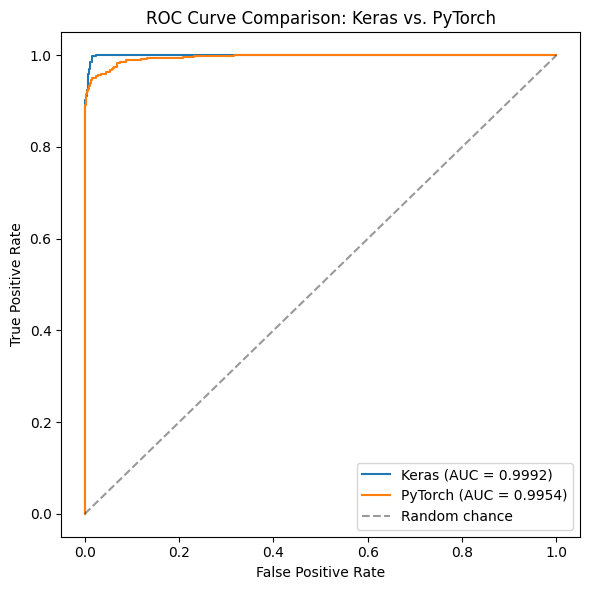

In [6]:
fpr_keras, tpr_keras, _ = roc_curve(y_true, keras_proba)
auc_keras = auc(fpr_keras, tpr_keras)

fpr_pt, tpr_pt, _ = roc_curve(y_true, pytorch_proba)
auc_pt = auc(fpr_pt, tpr_pt)

plt.figure(figsize=(6, 6))
plt.plot(fpr_keras, tpr_keras, label=f"Keras (AUC = {auc_keras:.4f})")
plt.plot(fpr_pt, tpr_pt, label=f"PyTorch (AUC = {auc_pt:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Keras vs. PyTorch")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Side-by-side comparison table

In [7]:
print(f"{'Metric':<12}{'Keras':<12}{'PyTorch':<12}")
print("-" * 36)
metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
for name, k, p in zip(metric_names, keras_metrics, pytorch_metrics):
    print(f"{name:<12}{k:<12.4f}{p:<12.4f}")
print(f"{'AUC':<12}{auc_keras:<12.4f}{auc_pt:<12.4f}")


Metric      Keras       PyTorch     
------------------------------------
Accuracy    0.9750      0.9600      
Precision   0.9928      0.9925      
Recall      0.9549      0.9236      
F1-score    0.9735      0.9568      
AUC         0.9992      0.9954      


## Summary

We compared two deep learning models -- one built and trained in Keras,
the other in PyTorch -- on the same held-out validation set, using
framework-independent metrics. This required careful attention to:

* **Data preparation** — using the *same* underlying split/seed for a
  fair comparison.
* **Model loading** — reconstructing the PyTorch architecture before
  loading its `state_dict`, versus Keras' self-contained `.keras` format.
* **Format alignment** — converting between channels-first (PyTorch) and
  channels-last (Keras) tensor layouts.
* **Metric computation & ROC visualization** — accuracy, precision,
  recall, F1, and ROC/AUC, all computed identically regardless of which
  framework produced the underlying probabilities.

Using these framework-independent metrics, we can fairly evaluate models
built in different frameworks side by side.
